# Airline Passenger Review Analysis

**Dataset:** ETM1005_A2_AirlineReviews.csv  
**Analysis sample:** 600 passenger reviews  
**Focus area:** Value For Money  

I am interested in airlines and wanted to see whether passengers' Value For Money ratings showed a similar pattern across airline groups. This notebook uses only the analysis sample and does not use outside information about the airlines.

## 1. Management context and evidence base

The main question is:

> What are the main passenger-experience concerns in my sample, and where should management begin reviewing low Value For Money experiences?

I first examine Overall Rating, recommendation and travel class. I then assess Value For Money, check whether its relationship with recommendation remains within airline groups, and examine selected review words and their meaning.

The intended decision is where to begin a closer review of passenger problems. The analysis cannot establish which service area deserves the airline's overall highest priority, because Value For Money is the selected focus area.

Each row is one review, not necessarily one unique passenger. The notebook creates a fixed sample using a reproducible random seed. Record_ID allows individual reviews to be located again.

The analysis uses Python, Pandas, descriptive statistics, and data visualization.

### 1.1 Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

Matplotlib is building the font cache; this may take a moment.


### 1.2 Create a reproducible analysis sample

Before running the notebook, place the authorized CSV file in the project folder using the exact filename `ETM1005_A2_AirlineReviews.csv`.

The sample uses a fixed random seed so the results are reproducible.

In [2]:
import pandas as pd
df = pd.read_csv("ETM1005_A2_AirlineReviews.csv")

SAMPLE_SEED = 39
FOCUS_SERVICE = "Value For Money"

# Create a stable record identifier before sampling
df = df.reset_index(drop=True).copy()
df["Record_ID"] = df.index + 1

# Reproducible sample
df_sub = df.sample(n=600, random_state=SAMPLE_SEED).copy().reset_index(drop=True)

assigned_service = FOCUS_SERVICE

### 1.3 Check the sample

I check the sample size, duplicate IDs, missing values and rating ranges before starting the analysis.

In [3]:
print("Assigned service:", assigned_service)
print("Sample shape:", df_sub.shape)
print("Unique Record_ID values:", len(set(df_sub["Record_ID"])))
print("Total missing values:", df_sub.isnull().sum().sum())

invalid_overall = 0
invalid_vfm = 0
blank_reviews = 0

for value in df_sub["Overall Rating"]:
    if value not in range(1, 11):
        invalid_overall = invalid_overall + 1

for value in df_sub[assigned_service]:
    if value not in range(1, 6):
        invalid_vfm = invalid_vfm + 1

for review in df_sub["Reviews"]:
    if str(review).strip() == "":
        blank_reviews = blank_reviews + 1

print("Invalid Overall Rating scores:", invalid_overall)
print("Invalid Value For Money scores:", invalid_vfm)
print("Blank review texts:", blank_reviews)

review_counts = df_sub["Reviews"].value_counts()

print(
    "Exact review texts appearing more than once:",
    (review_counts > 1).sum()
)

for column in ["Airline", "Class", "Recommended"]:
    original_labels = set(df_sub[column])
    checked_labels = []
    extra_spaces = 0

    for value in df_sub[column]:
        label = str(value)

        if label != label.strip():
            extra_spaces = extra_spaces + 1

        checked_labels.append(label.strip().lower())

    print()
    print(column, "labels:", sorted(original_labels))
    print("Rows with extra outer spaces:", extra_spaces)
    print(
        "Unique labels before and after checking case and spaces:",
        len(original_labels),
        len(set(checked_labels))
    )

Assigned service: Value For Money
Sample shape: (600, 17)
Unique Record_ID values: 600
Total missing values: 0
Invalid Overall Rating scores: 0
Invalid Value For Money scores: 0
Blank review texts: 0
Exact review texts appearing more than once: 0

Airline labels: ['Air France', 'All Nippon Airways', 'Cathay Pacific Airways', 'EVA Air', 'Emirates', 'Japan Airlines', 'Korean Air', 'Qatar Airways', 'Singapore Airlines', 'Turkish Airlines']
Rows with extra outer spaces: 0
Unique labels before and after checking case and spaces: 10 10

Class labels: ['Business Class', 'Economy Class', 'First Class', 'Premium Economy']
Rows with extra outer spaces: 0
Unique labels before and after checking case and spaces: 4 4

Recommended labels: ['no', 'yes']
Rows with extra outer spaces: 0
Unique labels before and after checking case and spaces: 2 2


The sample contains 600 rows and 600 unique Record_ID values. There are no missing values, blank review texts or exact review texts appearing more than once. Overall Rating and Value For Money contain only scores on their stated scales.

There are 10 airline labels, four travel-class labels and two recommendation labels. Checking letter case and outer spaces does not change the number of labels. The recommendation values are `yes` and `no`.

These checks found no obvious formatting problem that would split the displayed categories into separate groups. They do not independently verify whether the original airline and class labels are correct. All supplied rows and labels are retained.

All later calculations use df_sub or groups created from it.

## 2. Passenger experience diagnosis

### 2.1 Recommendation and Overall Rating

Recommendation records whether a reviewer recommends the airline. Overall Rating describes the reviewer's overall experience. I examine both because an average rating alone may hide very different experiences.

In [4]:
recommendation_counts = df_sub["Recommended"].value_counts()

recommendation_percentages = (
    df_sub["Recommended"].value_counts(normalize=True) * 100
)

recommendation_summary = pd.DataFrame({
    "Count": recommendation_counts,
    "Percentage": recommendation_percentages.round(2)
})

overall_summary = (
    df_sub["Overall Rating"].describe().round(2)
)

overall_mode = (
    df_sub["Overall Rating"].mode()[0]
)

overall_iqr = (
    df_sub["Overall Rating"].quantile(0.75)
    - df_sub["Overall Rating"].quantile(0.25)
)

overall_counts = (
    df_sub["Overall Rating"]
    .value_counts()
    .sort_index()
)

overall_percentages = (
    df_sub["Overall Rating"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

overall_frequency = pd.DataFrame({
    "Count": overall_counts,
    "Percentage": overall_percentages.round(2)
})

print("Recommendation summary")
print(recommendation_summary)

print()
print("Overall Rating summary")
print(overall_summary)
print("Mode:", overall_mode)
print("IQR:", round(overall_iqr, 2))

print()
print("Overall Rating frequencies")
print(overall_frequency)

Recommendation summary
             Count  Percentage
Recommended                   
yes            304       50.67
no             296       49.33

Overall Rating summary
count    600.00
mean       5.38
std        3.52
min        1.00
25%        2.00
50%        5.00
75%        9.00
max       10.00
Name: Overall Rating, dtype: float64
Mode: 1
IQR: 7.0

Overall Rating frequencies
                Count  Percentage
Overall Rating                   
1                 148       24.67
2                  55        9.17
3                  42        7.00
4                  26        4.33
5                  30        5.00
6                  20        3.33
7                  43        7.17
8                  62       10.33
9                  70       11.67
10                104       17.33


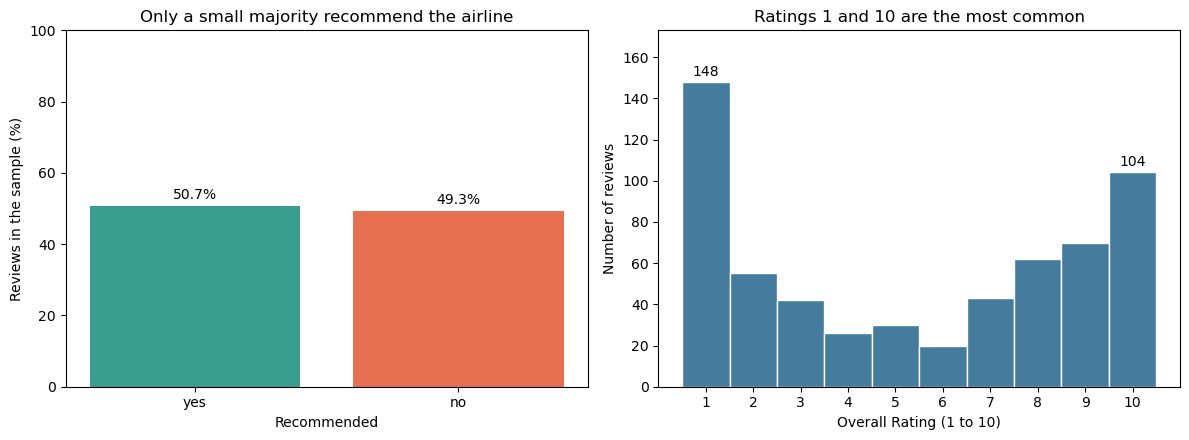

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

recommendation_plot = recommendation_percentages.reindex(["yes", "no"])

axes[0].bar(
    recommendation_plot.index,
    recommendation_plot.values,
    color=["#3a9d8f", "#e76f51"]
)

axes[0].set_title("Only a small majority recommend the airline")
axes[0].set_xlabel("Recommended")
axes[0].set_ylabel("Reviews in the sample (%)")
axes[0].set_ylim(0, 100)

for position, value in enumerate(recommendation_plot.values):
    axes[0].text(
        position, value + 2,
        f"{value:.1f}%",
        ha="center"
    )

axes[1].hist(
    df_sub["Overall Rating"],
    bins=np.arange(0.5, 11.5, 1),
    color="#457b9d",
    edgecolor="white"
)

axes[1].set_title("Ratings 1 and 10 are the most common")
axes[1].set_xlabel("Overall Rating (1 to 10)")
axes[1].set_ylabel("Number of reviews")
axes[1].set_xticks(range(1, 11))
axes[1].set_ylim(0, overall_counts.max() + 25)

for rating in [1, 10]:
    count = overall_counts.loc[rating]
    axes[1].text(
        rating, count + 3,
        str(count),
        ha="center"
    )

plt.tight_layout()
plt.show()

**Interpretation.**

Out of 600 reviews, 338 recommended the airline and 262 did not. The recommendation rate is 56.33%.

The mean Overall Rating is 5.80 and the median is 7. These two numbers do not show the whole pattern. Rating 1 is the most common score with 126 reviews, while rating 10 is almost as common with 123 reviews. The IQR is 7, so the ratings are widely spread.

Passenger experience is mixed. A small majority recommends the airline, but 43.67% does not. I next compare travel classes to see whether this pattern is the same across passenger groups.

### 2.2 Passenger experience by travel class

I compare travel classes to see whether passenger experience differs across groups in my sample. I include the sample sizes because results from small groups can change easily.

In [6]:
class_sizes = (
    df_sub["Class"].value_counts()
)

class_recommendation = pd.crosstab(
    df_sub["Class"],
    df_sub["Recommended"],
    normalize="index"
) * 100

class_overall_mean = (
    df_sub.groupby("Class")["Overall Rating"].mean()
)

class_summary = pd.DataFrame({
    "Sample Size": class_sizes,
    "Recommended Yes %": class_recommendation["yes"],
    "Overall Rating Mean": class_overall_mean
})

class_summary = (
    class_summary
    .sort_values("Sample Size", ascending=False)
    .round(2)
)

print(class_summary)

                 Sample Size  Recommended Yes %  Overall Rating Mean
Class                                                               
Economy Class            414              44.69                 4.97
Business Class           158              65.82                 6.35
Premium Economy           16              50.00                 5.62
First Class               12              58.33                 6.08


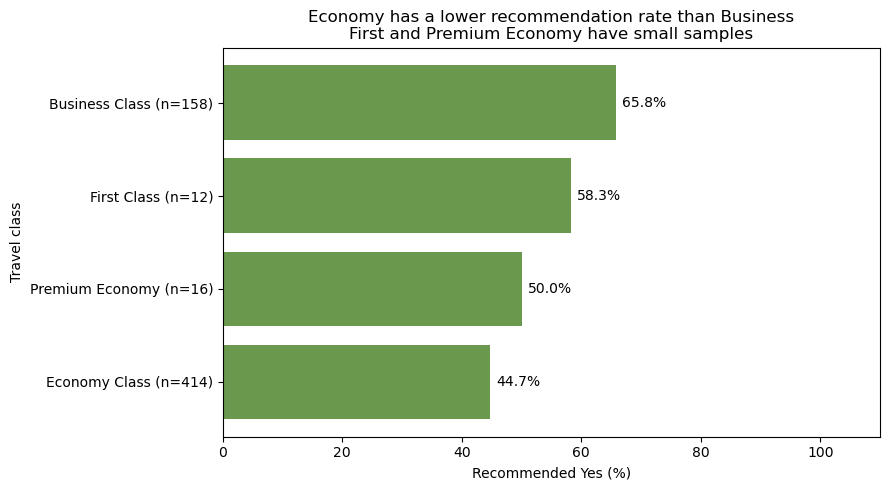

In [7]:
class_plot = class_summary.sort_values("Recommended Yes %")
class_labels = []

for class_name in class_plot.index:
    class_size = int(class_plot.loc[class_name, "Sample Size"])
    class_labels.append(f"{class_name} (n={class_size})")

positions = np.arange(len(class_plot))

plt.figure(figsize=(9, 5))

plt.barh(
    positions,
    class_plot["Recommended Yes %"],
    color="#6a994e"
)

plt.yticks(positions, class_labels)
plt.title(
    "Economy has a lower recommendation rate than Business\n"
    "First and Premium Economy have small samples"
)
plt.xlabel("Recommended Yes (%)")
plt.ylabel("Travel class")
plt.xlim(0, 110)

for position, value in enumerate(class_plot["Recommended Yes %"]):
    plt.text(
        value + 1, position,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

**Interpretation.**

Economy Class has 399 reviews, a recommendation rate of 50.38% and a mean Overall Rating of 5.35. Business Class has 176 reviews, a recommendation rate of 67.61% and a mean Overall Rating of 6.66.

The recommendation-rate difference is 17.23 percentage points. Economy is both the largest group and the weaker of these two groups, so its experience deserves attention.

Premium Economy has only 19 reviews and First Class has six. The 100% First Class recommendation rate therefore provides much less evidence than its position at the top of the chart might suggest.

The Economy and Business comparison does not show that travel class caused the difference. Airlines, routes and other passenger circumstances may differ between these groups. I keep travel class as background information when examining individual comments, without assuming that Economy explains the later airline results.

## 3. Service performance assessment: Value For Money

### 3.1 Distribution of Value For Money

Value For Money is rated from 1 to 5. I use three groups:

- Low: ratings 1 to 2
- Middle: rating 3
- High: ratings 4 to 5

This keeps the middle score separate and groups the two scores at each end of the scale. These are analysis groups, not targets supplied by an airline.

All 600 reviews remain in the full distribution and the score-by-score recommendation table. Only the low-versus-high comparisons exclude the 82 middle-score reviews. Those comparisons describe the ends of the scale, not all passengers.

In [8]:
vfm_summary = (
    df_sub[assigned_service].describe().round(2)
)

vfm_iqr = (
    df_sub[assigned_service].quantile(0.75)
    - df_sub[assigned_service].quantile(0.25)
)

vfm_counts = (
    df_sub[assigned_service]
    .value_counts()
    .sort_index()
)

vfm_percentages = (
    df_sub[assigned_service]
    .value_counts(normalize=True)
    .sort_index() * 100
)

vfm_frequency = pd.DataFrame({
    "Count": vfm_counts,
    "Percentage": vfm_percentages.round(2)
})

vfm_groups = []

for rating in df_sub[assigned_service]:
    if rating <= 2:
        vfm_groups.append("Low")
    elif rating >= 4:
        vfm_groups.append("High")
    else:
        vfm_groups.append("Middle")

df_sub["VFM Group"] = vfm_groups

low_vfm_count = (
    (df_sub["VFM Group"] == "Low").sum()
)

high_vfm_count = (
    (df_sub["VFM Group"] == "High").sum()
)

low_vfm_rate = (
    low_vfm_count / len(df_sub) * 100
)

high_vfm_rate = (
    high_vfm_count / len(df_sub) * 100
)

print("Value For Money summary")
print(vfm_summary)
print("IQR:", round(vfm_iqr, 2))

print()
print("Value For Money frequencies")
print(vfm_frequency)

print()
print(
    "Low ratings (1 to 2):",
    low_vfm_count,
    f"({low_vfm_rate:.2f}%)"
)

print(
    "High ratings (4 to 5):",
    high_vfm_count,
    f"({high_vfm_rate:.2f}%)"
)

Value For Money summary
count    600.00
mean       3.06
std        1.62
min        1.00
25%        1.00
50%        3.00
75%        5.00
max        5.00
Name: Value For Money, dtype: float64
IQR: 4.0

Value For Money frequencies
                 Count  Percentage
Value For Money                   
1                  183       30.50
2                   53        8.83
3                   78       13.00
4                  117       19.50
5                  169       28.17

Low ratings (1 to 2): 236 (39.33%)
High ratings (4 to 5): 286 (47.67%)


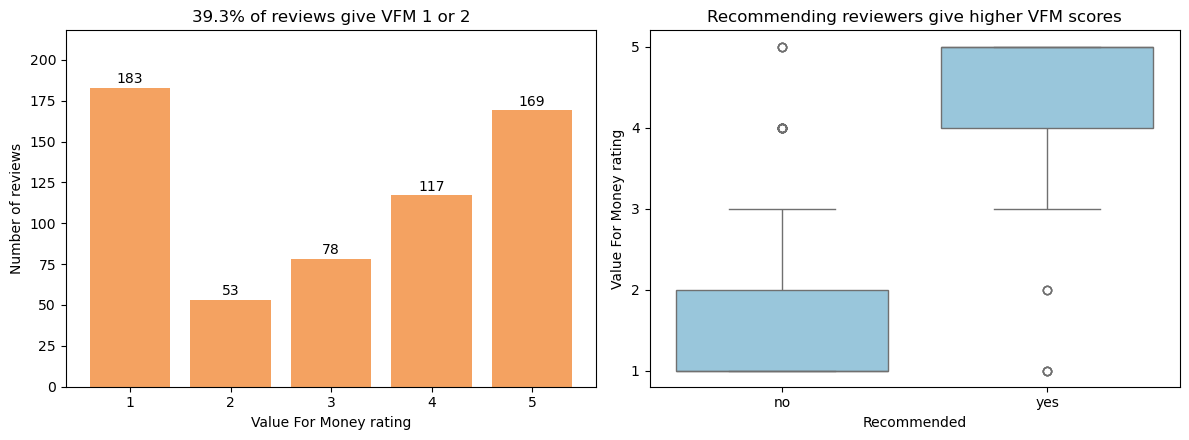

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(
    vfm_counts.index,
    vfm_counts.values,
    color="#f4a261"
)

axes[0].set_title(
    f"{low_vfm_rate:.1f}% of reviews give VFM 1 or 2"
)
axes[0].set_xlabel("Value For Money rating")
axes[0].set_ylabel("Number of reviews")
axes[0].set_xticks(range(1, 6))
axes[0].set_ylim(0, vfm_counts.max() + 35)

for rating in vfm_counts.index:
    count = vfm_counts.loc[rating]
    axes[0].text(
        rating,
        count + 3,
        str(count),
        ha="center"
    )

sns.boxplot(
    data=df_sub,
    x="Recommended",
    y=assigned_service,
    order=["no", "yes"],
    color="#8ecae6",
    ax=axes[1]
)

axes[1].set_title(
    "Recommending reviewers give higher VFM scores"
)
axes[1].set_xlabel("Recommended")
axes[1].set_ylabel("Value For Money rating")
axes[1].set_yticks(range(1, 6))

plt.tight_layout()
plt.show()

**Interpretation.**

The mean Value For Money score is 3.25 and the median is 4. The median looks fairly positive, although the full distribution is mixed.

Rating 5 is the most common result with 205 reviews. Rating 1 is the second most common with 143 reviews.

There are 214 low ratings, equal to 35.67% of the sample. There are 304 high ratings, equal to 50.67%.

High ratings are more common, but more than one-third of passengers gave a score of only 1 or 2. Inconsistent Value For Money is therefore an issue worth examining.

### 3.2 Value For Money and the wider passenger experience

I compare Value For Money with recommendation and Overall Rating. The recommendation percentages are calculated within each Value For Money score. Pearson correlation is used for the two numerical ratings.

In [10]:
vfm_by_recommendation = (
    df_sub.groupby("Recommended")[assigned_service]
    .describe()[["count", "mean", "50%"]]
    .round(2)
)

vfm_recommendation_table = pd.crosstab(
    df_sub[assigned_service],
    df_sub["Recommended"],
    normalize="index"
) * 100

vfm_recommendation_table = (
    vfm_recommendation_table.round(2)
)

vfm_overall_correlation = (
    df_sub[
        [assigned_service, "Overall Rating"]
    ]
    .corr()
    .loc[assigned_service, "Overall Rating"]
)

print("Value For Money by recommendation group")
print(vfm_by_recommendation)

print()
print(
    "Recommendation percentages within "
    "each Value For Money score"
)
print(vfm_recommendation_table)

print()
print(
    "Pearson correlation with Overall Rating:",
    round(vfm_overall_correlation, 3)
)

Value For Money by recommendation group
             count  mean  50%
Recommended                  
no           296.0  1.70  1.0
yes          304.0  4.38  5.0

Recommendation percentages within each Value For Money score
Recommended         no    yes
Value For Money              
1                97.81   2.19
2                94.34   5.66
3                61.54  38.46
4                12.82  87.18
5                 2.37  97.63

Pearson correlation with Overall Rating: 0.883


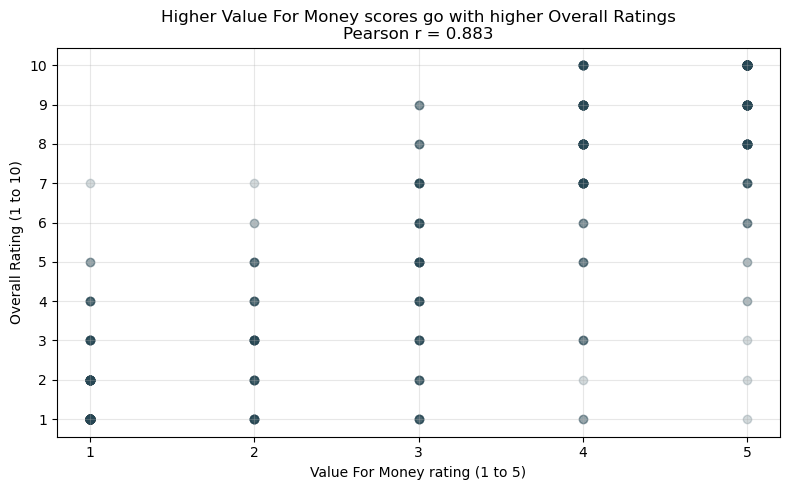

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_sub[assigned_service],
    df_sub["Overall Rating"],
    alpha=0.20,
    color="#264653"
)

plt.title(
    "Higher Value For Money scores go with higher Overall Ratings\n"
    f"Pearson r = {vfm_overall_correlation:.3f}"
)
plt.xlabel("Value For Money rating (1 to 5)")
plt.ylabel("Overall Rating (1 to 10)")
plt.xticks(range(1, 6))
plt.yticks(range(1, 11))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation.**

Passengers who did not recommend had a mean Value For Money score of 1.75 and a median of 1. Passengers who recommended had a mean of 4.42 and a median of 5.

Only 3.50% of reviews with a Value For Money score of 1 recommended the airline. The recommendation rate reaches 99.02% when the score is 5.

The Pearson correlation between Value For Money and Overall Rating is 0.889. This indicates a very strong positive relationship.

Some points overlap in the scatter plot because both ratings use whole numbers. The general pattern is still visible. Low Value For Money scores mostly appear with low Overall Ratings, and high scores mostly appear with high Overall Ratings.

Value For Money is strongly related to the wider passenger experience in this sample. Other service experiences may affect both ratings, so the result does not prove cause.

## 4. Further analysis for management

### 4.1 Compare airline groups

I compare the airline groups to see where low Value For Money ratings are more common. The table includes every airline. The chart only includes airlines with at least 50 reviews because percentages from very small groups can change easily.

In [12]:
airline_sizes = (
    df_sub["Airline"].value_counts()
)

airline_vfm_mean = (
    df_sub.groupby("Airline")[assigned_service].mean()
)

airline_vfm_table = pd.crosstab(
    df_sub["Airline"],
    df_sub["VFM Group"],
    normalize="index"
) * 100

airline_rec_table = pd.crosstab(
    df_sub["Airline"],
    df_sub["Recommended"],
    normalize="index"
) * 100

airline_summary = pd.DataFrame({
    "Sample Size": airline_sizes,
    "VFM Mean": airline_vfm_mean,
    "Low VFM %": airline_vfm_table["Low"],
    "Recommended Yes %": airline_rec_table["yes"]
})

airline_summary = (
    airline_summary
    .sort_values("Sample Size", ascending=False)
    .round(2)
)

two_airline_rows = df_sub[
    (df_sub["Airline"] == "Turkish Airlines")
    | (df_sub["Airline"] == "Emirates")
]

two_airline_sample_share = (
    len(two_airline_rows) / len(df_sub) * 100
)

two_airline_low_count = len(
    two_airline_rows[
        two_airline_rows["VFM Group"] == "Low"
    ]
)

two_airline_low_share = (
    two_airline_low_count / low_vfm_count * 100
)

print(airline_summary)

print()
print(
    "Turkish Airlines and Emirates share "
    "of all reviews:",
    f"{two_airline_sample_share:.2f}%"
)

print(
    "Turkish Airlines and Emirates share "
    "of low-VFM reviews:",
    f"{two_airline_low_share:.2f}%"
)

                        Sample Size  VFM Mean  Low VFM %  Recommended Yes %
Airline                                                                    
Turkish Airlines                145      2.41      57.24              32.41
Qatar Airways                   108      3.71      24.07              68.52
Emirates                         96      2.88      42.71              40.62
Air France                       65      2.51      50.77              36.92
Singapore Airlines               63      3.11      39.68              52.38
Cathay Pacific Airways           53      3.45      28.30              67.92
EVA Air                          20      4.05      10.00              85.00
All Nippon Airways               19      4.37      10.53              84.21
Korean Air                       17      3.24      29.41              58.82
Japan Airlines                   14      3.43      28.57              57.14

Turkish Airlines and Emirates share of all reviews: 40.17%
Turkish Airlines and Emirate

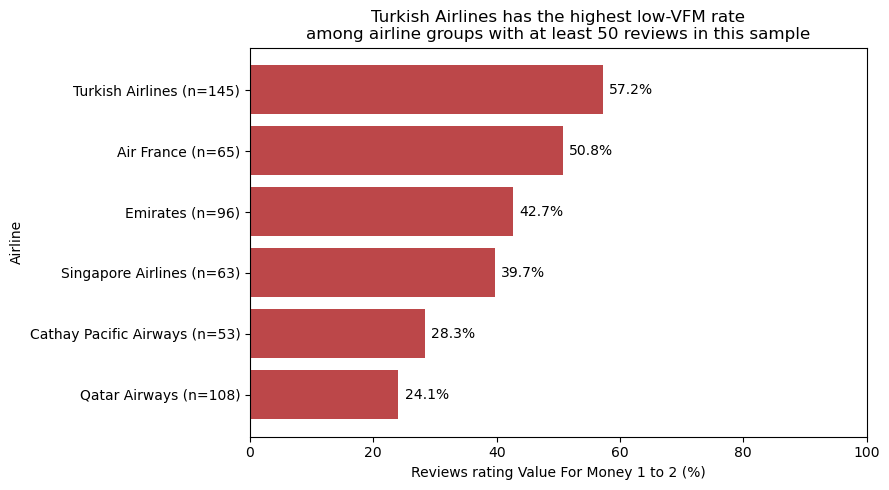

In [13]:
major_airlines = airline_summary[
    airline_summary["Sample Size"] >= 50
]

major_airlines = major_airlines.sort_values("Low VFM %")
airline_labels = []

for airline in major_airlines.index:
    size = int(major_airlines.loc[airline, "Sample Size"])
    airline_labels.append(f"{airline} (n={size})")

positions = np.arange(len(major_airlines))

plt.figure(figsize=(9, 5))

plt.barh(
    positions,
    major_airlines["Low VFM %"],
    color="#bc4749"
)

plt.yticks(positions, airline_labels)
plt.title(
    "Turkish Airlines has the highest low-VFM rate\n"
    "among airline groups with at least 50 reviews in this sample"
)
plt.xlabel("Reviews rating Value For Money 1 to 2 (%)")
plt.ylabel("Airline")
plt.xlim(0, 100)

for position, value in enumerate(major_airlines["Low VFM %"]):
    plt.text(
        value + 1, position,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [14]:
within_airline_results = []

for airline in major_airlines.index:
    airline_data = df_sub[
        df_sub["Airline"] == airline
    ]

    low_group = airline_data[
        airline_data["VFM Group"] == "Low"
    ]

    high_group = airline_data[
        airline_data["VFM Group"] == "High"
    ]

    low_rec_rate = (
        (low_group["Recommended"] == "yes").sum()
        / len(low_group) * 100
    )

    high_rec_rate = (
        (high_group["Recommended"] == "yes").sum()
        / len(high_group) * 100
    )

    within_airline_results.append({
        "Airline": airline,
        "Low VFM n": len(low_group),
        "Low VFM Recommended %": low_rec_rate,
        "High VFM n": len(high_group),
        "High VFM Recommended %": high_rec_rate,
        "Recommendation Gap":
            high_rec_rate - low_rec_rate
    })

within_airline_check = pd.DataFrame(
    within_airline_results
)

within_airline_check = (
    within_airline_check
    .sort_values("Recommendation Gap")
    .round(2)
)

minimum_recommendation_gap = (
    within_airline_check[
        "Recommendation Gap"
    ].min()
)

print(
    "Recommendation within low and high "
    "Value For Money groups"
)

print(
    within_airline_check.to_string(index=False)
)

print()
print(
    "Smallest recommendation gap:",
    f"{minimum_recommendation_gap:.2f} "
    "percentage points"
)

Recommendation within low and high Value For Money groups
               Airline  Low VFM n  Low VFM Recommended %  High VFM n  High VFM Recommended %  Recommendation Gap
      Turkish Airlines         83                   3.61          43                   86.05               82.43
         Qatar Airways         26                   7.69          73                   93.15               85.46
Cathay Pacific Airways         15                   6.67          30                   96.67               90.00
              Emirates         41                   0.00          38                   92.11               92.11
            Air France         33                   0.00          21                   95.24               95.24
    Singapore Airlines         25                   0.00          32                   96.88               96.88

Smallest recommendation gap: 82.43 percentage points


### 4.2 What the airline comparison shows

Turkish Airlines and Qatar Airways interested me because their sample sizes were similar but their results were very different. Turkish has 126 reviews, a mean Value For Money score of 2.38 and a low-rating rate of 61.11%. Qatar has 124 reviews, a mean of 4.02 and a low-rating rate of 12.90%.

Turkish Airlines and Emirates together account for 39.67% of all reviews but 60.28% of low Value For Money reviews. This makes their comments a useful starting point for reviewing low-value experiences in this sample. It does not establish that they have the worst current performance.

The chart uses 50 reviews as a practical display cutoff. It reduces attention to very small airline groups, but does not guarantee that every subgroup is large.

I checked whether airline mix could explain the overall Value For Money and recommendation relationship. Within each of the six larger airline groups, high-VFM reviews still had a much higher recommendation rate than low-VFM reviews. The smallest gap was 87.37 percentage points.

This check supports the direction of the relationship within airlines. I would not rank the strength of the relationship using these gaps: some subgroups are small, and rates of 0% or 100% need care. The comparison also excludes middle VFM scores and does not control for route, class or travel period. It therefore cannot explain why the airlines differ or establish causation.

### 4.3 Examine the review text

The numerical results identify where low ratings occur, but they do not explain the situations described by passengers.

I use a standard text-cleaning process: lowercase the text, remove punctuation, split it into words, remove stop words and count the remaining words. The same cleaning rules are used for the low and high groups.

I then compare four selected words: `ticket`, `luggage`, `delayed` and `cancelled`. They provide a manageable starting point for exploring ticket-related experiences, baggage and travel disruption. They are not the four most frequent words, and they do not cover every service issue.

Finally, I display the first matching low-VFM review for each word in the existing sample order. This gives a fixed rule for checking meaning instead of choosing examples because they support a preferred conclusion.

In [15]:
stop_words = set("""
a an the and or but if while of at by for with about
against between into through during before after above
below to from up down in out on off over under again
further then once here there when where why how all any
both each few more most other some such no nor not only
own same so than too very can will just should now i me
my myself we our ours ourselves you your yours yourself
yourselves he him his himself she her hers herself it
its itself they them their theirs themselves what which
who whom this that these those am is are was were be been
being have has had having do does did doing would could
ive im isnt arent wasnt werent havent hasnt hadnt wont
wouldnt dont doesnt didnt cant cannot couldnt flight
flights airline airlines fly flying flew one get got also
even us really much back still made make day way time
hour hours passenger passengers trip travel travelling
plane aircraft journey board boarding
""".split())


def extract_keywords(text):
    cleaned_text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        str(text).lower()
    )

    words = cleaned_text.split()
    keywords = []

    for word in words:
        if word not in stop_words and len(word) > 2:
            keywords.append(word)

    return keywords


low_keywords = []
high_keywords = []

for review in df_sub.loc[
    df_sub["VFM Group"] == "Low",
    "Reviews"
]:
    low_keywords.extend(
        extract_keywords(review)
    )

for review in df_sub.loc[
    df_sub["VFM Group"] == "High",
    "Reviews"
]:
    high_keywords.extend(
        extract_keywords(review)
    )

top_low_keywords = pd.DataFrame(
    Counter(low_keywords).most_common(15),
    columns=["Keyword", "Count"]
)

top_high_keywords = pd.DataFrame(
    Counter(high_keywords).most_common(15),
    columns=["Keyword", "Count"]
)

print(
    "Top keywords in low Value For Money reviews"
)
print(top_low_keywords)

print()
print(
    "Top keywords in high Value For Money reviews"
)
print(top_high_keywords)

Top keywords in low Value For Money reviews
     Keyword  Count
0    service    181
1    airport    133
2   istanbul    117
3    turkish    110
4   customer    108
5      check    108
6       told    105
7      staff    103
8       seat     98
9      class     97
10  business     94
11       via     91
12      food     88
13    ticket     88
14      crew     83

Top keywords in high Value For Money reviews
        Keyword  Count
0       service    226
1          good    208
2          crew    181
3          food    167
4         class    167
5          seat    153
6         cabin    148
7         seats    133
8         staff    124
9      business    120
10        great    119
11          via    105
12         doha    100
13  comfortable     99
14    excellent     96


The low and high groups contain 214 and 304 reviews. Raw keyword counts are therefore not directly comparable. One review may also repeat the same word several times.

Some frequent words, such as airline and airport names, describe the setting rather than a service problem. Words such as `service` and `staff` also need context before they can be treated as praise or complaints.

The next comparison counts each selected word at most once per review. The percentage is:

number of reviews containing the exact word / number of reviews in that VFM group × 100.

This adjusts for the different group sizes. It does not measure the percentage of passengers who experienced a particular problem.

In [16]:
def keyword_mention_rate(reviews, keyword):
    mention_count = 0

    for review in reviews:
        review_words = set(
            extract_keywords(review)
        )

        if keyword in review_words:
            mention_count = mention_count + 1

    return mention_count / len(reviews) * 100


selected_keywords = [
    "ticket",
    "luggage",
    "delayed",
    "cancelled"
]

low_reviews = df_sub.loc[
    df_sub["VFM Group"] == "Low",
    "Reviews"
]

high_reviews = df_sub.loc[
    df_sub["VFM Group"] == "High",
    "Reviews"
]

low_mention_rates = []
high_mention_rates = []

for keyword in selected_keywords:
    low_mention_rates.append(
        keyword_mention_rate(
            low_reviews,
            keyword
        )
    )

    high_mention_rates.append(
        keyword_mention_rate(
            high_reviews,
            keyword
        )
    )

keyword_comparison = pd.DataFrame({
    "Keyword": selected_keywords,
    "Low VFM Mention %": low_mention_rates,
    "High VFM Mention %": high_mention_rates
})

keyword_comparison[
    "Percentage-Point Gap"
] = (
    keyword_comparison["Low VFM Mention %"]
    - keyword_comparison["High VFM Mention %"]
)

keyword_comparison = (
    keyword_comparison.round(2)
)

print(keyword_comparison)

     Keyword  Low VFM Mention %  High VFM Mention %  Percentage-Point Gap
0     ticket              22.03                6.29                 15.74
1    luggage              19.49                4.55                 14.95
2    delayed              19.92                6.29                 13.62
3  cancelled              11.44                2.80                  8.64


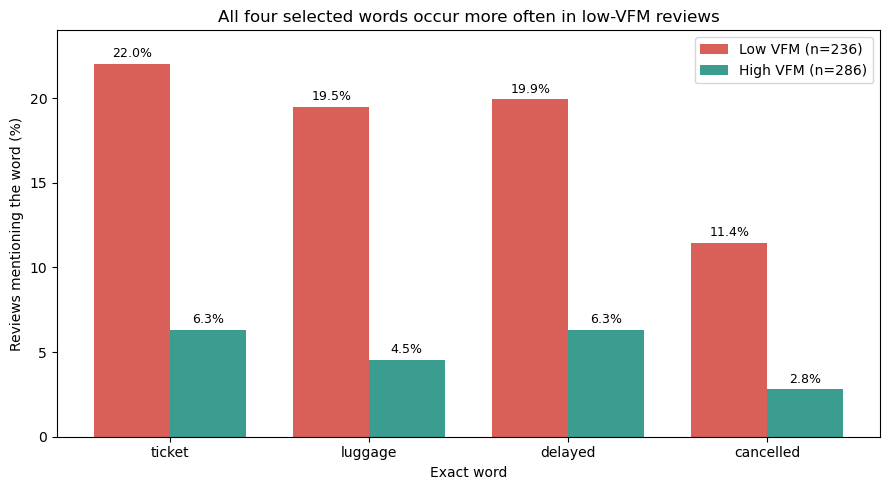

In [17]:
positions = np.arange(len(selected_keywords))
bar_width = 0.38

plt.figure(figsize=(9, 5))

plt.bar(
    positions - bar_width / 2,
    keyword_comparison["Low VFM Mention %"],
    width=bar_width,
    label=f"Low VFM (n={len(low_reviews)})",
    color="#d95f59"
)

plt.bar(
    positions + bar_width / 2,
    keyword_comparison["High VFM Mention %"],
    width=bar_width,
    label=f"High VFM (n={len(high_reviews)})",
    color="#3a9d8f"
)

for position in positions:
    low_value = keyword_comparison.loc[position, "Low VFM Mention %"]
    high_value = keyword_comparison.loc[position, "High VFM Mention %"]

    plt.text(
        position - bar_width / 2,
        low_value + 0.4,
        f"{low_value:.1f}%",
        ha="center",
        fontsize=9
    )

    plt.text(
        position + bar_width / 2,
        high_value + 0.4,
        f"{high_value:.1f}%",
        ha="center",
        fontsize=9
    )

plt.title("All four selected words occur more often in low-VFM reviews")
plt.xlabel("Exact word")
plt.ylabel("Reviews mentioning the word (%)")
plt.xticks(positions, selected_keywords)
plt.ylim(0, 24)
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
matched_keyword_lists = []

for review in df_sub["Reviews"]:
    review_words = set(extract_keywords(review))
    matched_keywords = []

    for keyword in selected_keywords:
        if keyword in review_words:
            matched_keywords.append(keyword)

    matched_keyword_lists.append(", ".join(matched_keywords))

df_sub["Matched Keywords"] = matched_keyword_lists

checked_record_ids = []

print("First matching low-VFM review for each selected word")

for keyword in selected_keywords:
    for row_index in low_reviews.index:
        review = df_sub.loc[row_index, "Reviews"]

        if keyword in extract_keywords(review):
            record_id = int(df_sub.loc[row_index, "Record_ID"])
            checked_record_ids.append(record_id)

            print()
            print("Selected word:", keyword)
            print("Record_ID:", record_id)
            print("Airline:", df_sub.loc[row_index, "Airline"])
            print("Class:", df_sub.loc[row_index, "Class"])
            print("Value For Money:", df_sub.loc[row_index, assigned_service])
            print("Recommended:", df_sub.loc[row_index, "Recommended"])
            print("Matched Keywords:", df_sub.loc[row_index, "Matched Keywords"])
            print("Review:")
            print(review)
            break

First matching low-VFM review for each selected word

Selected word: ticket
Record_ID: 5305
Airline: Turkish Airlines
Class: Economy Class
Value For Money: 1
Recommended: no
Matched Keywords: ticket
Review:
 Be wary with this airline. It’s my second flight with Turkish Airlines. My first one was a few years ago and that was normal. This one was bad. I booked a return ticket from Hong Kong to Kiev via Istanbul but I had an accident in Kiev and needed to change to the next day. The only way to do this was calling the Call Centre. I thought they fly to Hong Kong every day. The Call Center only changed my first flight (Kiev to Istanbul) to the next day, but not the second one, which was changed to more than 24 hours after the first one. The staff didn’t clearly say there was no flight to Hong Kong on the next day at the beginning. I just noticed that immediately after I paid USD 266. I even hadn’t hung up the phone and asked for a change. The Call Centre told me they would charge another s

**Interpretation of the text results.**

The exact words `ticket`, `luggage`, `delayed` and `cancelled` occur in 16.82%, 14.95%, 16.82% and 12.15% of low-VFM reviews. The corresponding high-VFM percentages are 4.93%, 5.26%, 4.61% and 0.66%.

The largest gap is 12.22 percentage points for `delayed`. However, word presence alone does not establish what went wrong.

Record 4614 describes difficulty getting help with misspelled names on a ticket. Record 6113 describes difficulty obtaining help with storing luggage in the cabin. These examples do not establish that the ticket price was too high or that luggage was lost.

Record 5631 describes a delay, a missed connection and difficulty obtaining assistance during the wait. Record 7242 describes a cancellation followed by problems with hotel vouchers. Both accounts raise questions about assistance after disruption.

The examples make the next investigation more specific: check how passengers received help when problems occurred. They are passenger accounts, not independently verified events. Four selected comments cannot establish the most common problem or explain all low-VFM ratings.

## 5. Management judgement

The evidence supports investigating low Value For Money experiences. Low scores account for 214 reviews, or 35.67% of the sample, even though high scores are more common.

The concern is also connected with the wider experience. Value For Money has a correlation of 0.889 with Overall Rating, and recommendation rises from 3.50% at VFM 1 to 99.02% at VFM 5. The low-versus-high recommendation difference remains large within all six larger airline groups.

My immediate recommendation is to review more low-VFM comments for repeated difficulties obtaining help. The four words provide an initial way to find cases, but comments without these words should also be read so that other problems are not missed.

Turkish Airlines and Emirates are useful starting groups because they contribute 60.28% of low-VFM reviews in this sample. Travel class should be retained as background information: Economy has a weaker overall recommendation result, but this analysis has not shown that class explains the airline differences.

Qatar's stronger results can identify comparison cases. They do not establish a specific practice to copy. Routes, classes and travel circumstances should be considered before drawing lessons from those cases.

If further reading confirms a repeated handling problem, management can investigate that process before selecting a change. The data contain no actual ticket-price or cost information, so they do not justify a general fare reduction.

### Limits and confidence

I have high confidence in the calculated relationships within this sample, with lower confidence about their causes or the best operational response.

The reviews come from people who chose to post online and may not represent all passengers. They combine airlines, routes and travel periods, so the airline percentages are not current performance scores.

Checking labels for formatting does not independently verify the original classifications. Airline and class differences may also reflect other conditions that were not examined.

The text analysis counts exact words, misses related forms and does not measure sentiment. The four displayed reviews illustrate possible meanings; they do not measure how common those meanings are.

Value For Money is the only service area evaluated in detail. The results cannot rank it above other service areas or show that changing it would cause recommendation to improve.

## 6. Results Fingerprint

In [19]:
print("RESULTS FINGERPRINT")
print("-------------------")

print("Sample size:", len(df_sub))
print("Unique Record_ID values:", len(set(df_sub["Record_ID"])))
print("Assigned service:", assigned_service)

print()
print("PASSENGER EXPERIENCE")
print(f"Recommended yes: {recommendation_percentages['yes']:.2f}%")
print(f"Recommended no: {recommendation_percentages['no']:.2f}%")
print(f"Overall Rating mean: {df_sub['Overall Rating'].mean():.2f}")
print(f"Overall Rating median: {df_sub['Overall Rating'].median():.2f}")
print(f"Overall Rating IQR: {overall_iqr:.2f}")

print()
print("VALUE FOR MONEY")
print(f"Mean: {df_sub[assigned_service].mean():.2f}")
print(f"Median: {df_sub[assigned_service].median():.2f}")
print(f"Low ratings 1 to 2: {low_vfm_count} ({low_vfm_rate:.2f}%)")
print(f"High ratings 4 to 5: {high_vfm_count} ({high_vfm_rate:.2f}%)")

print(
    "Mean for Recommended=no:",
    f"{vfm_by_recommendation.loc['no', 'mean']:.2f}"
)
print(
    "Mean for Recommended=yes:",
    f"{vfm_by_recommendation.loc['yes', 'mean']:.2f}"
)
print(
    "Recommendation at VFM=1:",
    f"{vfm_recommendation_table.loc[1, 'yes']:.2f}%"
)
print(
    "Recommendation at VFM=5:",
    f"{vfm_recommendation_table.loc[5, 'yes']:.2f}%"
)
print(f"Correlation with Overall Rating: {vfm_overall_correlation:.3f}")

print()
print("FURTHER CHECKS")
print(
    "Turkish Airlines low-VFM rate:",
    f"{airline_summary.loc['Turkish Airlines', 'Low VFM %']:.2f}%"
)
print(
    "Qatar Airways low-VFM rate:",
    f"{airline_summary.loc['Qatar Airways', 'Low VFM %']:.2f}%"
)
print(
    "Turkish Airlines and Emirates share of low-VFM reviews:",
    f"{two_airline_low_share:.2f}%"
)
print(
    "Smallest within-airline recommendation gap:",
    f"{minimum_recommendation_gap:.2f} percentage points"
)

print()
print("SELECTED WORDS")
print(keyword_comparison.to_string(index=False))
print("Record_ID values for the displayed review checks:", checked_record_ids)

print()
print(
    "Priority within Value For Money: review more low-VFM comments "
    "for repeated difficulties obtaining help. Start with matched "
    "comments, but include comments without these words."
)

RESULTS FINGERPRINT
-------------------
Sample size: 600
Unique Record_ID values: 600
Assigned service: Value For Money

PASSENGER EXPERIENCE
Recommended yes: 50.67%
Recommended no: 49.33%
Overall Rating mean: 5.38
Overall Rating median: 5.00
Overall Rating IQR: 7.00

VALUE FOR MONEY
Mean: 3.06
Median: 3.00
Low ratings 1 to 2: 236 (39.33%)
High ratings 4 to 5: 286 (47.67%)
Mean for Recommended=no: 1.70
Mean for Recommended=yes: 4.38
Recommendation at VFM=1: 2.19%
Recommendation at VFM=5: 97.63%
Correlation with Overall Rating: 0.883

FURTHER CHECKS
Turkish Airlines low-VFM rate: 57.24%
Qatar Airways low-VFM rate: 24.07%
Turkish Airlines and Emirates share of low-VFM reviews: 52.54%
Smallest within-airline recommendation gap: 82.43 percentage points

SELECTED WORDS
  Keyword  Low VFM Mention %  High VFM Mention %  Percentage-Point Gap
   ticket              22.03                6.29                 15.74
  luggage              19.49                4.55                 14.95
  delayed   